In [ ]:
!pip install pennylane pennylane-lightning-gpu


In [ ]:
# ── Cell 2 : Imports & Global Configuration ──────────────────────────
import os
import sys
import math
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load

import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found — UMAP visualization will be skipped.', ImportWarning)

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Dataset path — override via env variable ─────────────────────────
DATASET_PATH = os.environ.get(
    'DATASET_PATH',
    '/dataset_encoded_normalized1.csv'
)

# ── Quantum circuit hyperparameters ──────────────────────────────────
N_LAYERS     = 2          # default
ENTANGLEMENT = 'circular' # default
DE_MAXITER   = 20
DE_POPSZ     = 10
N_SPLITS_CV  = 5
EPS          = 1e-12      # zero-vector guard (kept from original)

# ── Cache ───────────────────────────────────────────────────────
CACHE_DIR = 'cache_quantum_amplitude_dt_pub'
os.makedirs(CACHE_DIR, exist_ok=True)

WEIGHTS_FILE         = os.path.join(CACHE_DIR, 'best_weights.npy')
MODEL_CLASSICAL_FILE = os.path.join(CACHE_DIR, 'dt_classical.joblib')
MODEL_HYBRID_FILE    = os.path.join(CACHE_DIR, 'dt_hybrid.joblib')

FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane version : {qml.version()}')
print(f'Python            : {sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'Dataset path      : {DATASET_PATH}')
print(f'Cache directory   : {os.path.abspath(CACHE_DIR)}')

PennyLane version : 0.44.1
Python            : 3.13.11
NumPy             : 2.4.1
Dataset path      : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache directory   : /home/host1-vm4/cache_quantum_amplitude_dt_pub


In [ ]:
# ── Cell 3 : Data Loading, Amplitude Padding & 3-Way Split (70 / 15 / 15) ──
#
# FIX 1 (padding): pad_features applied to X_raw BEFORE split so all
#   sets share dim_amplitude consistently.
#
# FIX 2 (data leakage): strict 3-way split:
#   X_train (70%) — DE optimization + final DT training
#   X_val   (15%) — DE objective evaluation ONLY
#   X_test  (15%) — final holdout, touched ONCE at the very end
#
# FIX 3: hashlib.md5 on raw array bytes (faster + reproducible)
#   replacing pd.util.hash_pandas_object which includes index noise.

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set the DATASET_PATH env variable or update the default path.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]

# Amplitude encoding qubit count
n_qubits  = math.ceil(math.log2(max(1, N_FEATURES)))
dim_amp   = 2 ** n_qubits

# FIX: hash raw array bytes — stable across runs
HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

print(f'Dataset      : {X_raw.shape[0]} samples × {N_FEATURES} features')
print(f'Target       : LN_IC50  mean={Y.mean():.3f}  std={Y.std():.3f}')
print(f'Hash         : {HASH}')
print(f'n_qubits     : {n_qubits}  (ceil(log₂({N_FEATURES})))')
print(f'dim_amplitude: {dim_amp}  (padded from {N_FEATURES})')

# FIX: padding BEFORE split
def pad_features(x, target_len=dim_amp):
    """Zero-pad a feature vector to target_len (next power of 2)."""
    padded = np.zeros(target_len)
    padded[:len(x)] = x
    return padded

X_padded = np.array([pad_features(xi) for xi in X_raw])

# 70 / 15 / 15 split
X_tr_p, X_temp, Y_train, Y_temp = train_test_split(
    X_padded, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_p, X_test_p, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

X_train, X_val, X_test = X_tr_p, X_val_p, X_test_p

print(f'\nSplit — Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('X_test will be touched ONCE at the final evaluation cell.')

X_TRAIN_Q_FILE = os.path.join(CACHE_DIR, f'X_train_q_{HASH}.npy')
X_VAL_Q_FILE   = os.path.join(CACHE_DIR, f'X_val_q_{HASH}.npy')
X_TEST_Q_FILE  = os.path.join(CACHE_DIR, f'X_test_q_{HASH}.npy')

Dataset      : 13106 samples × 12 features
Target       : LN_IC50  mean=0.538  std=0.134
Hash         : 8f057170
n_qubits     : 4  (ceil(log₂(12)))
dim_amplitude: 16  (padded from 12)

Split — Train: 9174  Val: 1966  Test: 1966
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device Initialization ─────────────────────────────
#
# FIX: shots=None removed from device init.
#   lightning.gpu defaults to statevector simulation (no shots needed).
#   Passing shots=None explicitly causes deprecation warnings in newer
#   PennyLane versions.

try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU device ready : lightning.gpu | {n_qubits} qubits')
except Exception as e:
    warnings.warn(
        f'GPU device unavailable ({e}). Falling back to lightning.qubit (CPU).',
        RuntimeWarning
    )
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'

dev_cpu = qml.device('default.qubit', wires=n_qubits)

print(f'Active device    : {DEVICE_LABEL}')
print(f'n_qubits         : {n_qubits}  ({dim_amp} amplitudes → {n_qubits} PauliZ features)')
print(f'Benchmark device : default.qubit (CPU reference)')

GPU device ready : lightning.gpu | 4 qubits
Active device    : lightning.gpu
n_qubits         : 4  (16 amplitudes → 4 PauliZ features)
Benchmark device : default.qubit (CPU reference)


In [ ]:
# ── Cell 5 : Amplitude Encoding Circuit Factory ─────────────────────────
#
# FIX: QNode built via build_amplitude_circuit() factory.
# FIX: shots=None removed (statevector is the default).
# FIX: configurable entanglement topology for ablation study.
# EPS guard from original preserved (EPS=1e-12 as set in Cell 2).

def build_amplitude_circuit(device, topology='circular'):
    """Build an amplitude-encoding QNode on `device`."""

    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        # Per-sample L2 normalization (AmplitudeEmbedding needs unit-norm)
        norm = np.linalg.norm(x)
        x_norm = (x / norm) if norm >= EPS else (np.ones_like(x) / np.sqrt(len(x)))

        qml.AmplitudeEmbedding(features=x_norm, wires=range(n_qubits), normalize=False)

        n_layers = weights.shape[0]
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)

            if topology == 'linear':
                if n_qubits > 1:
                    for i in range(n_qubits - 1):
                        qml.CNOT(wires=[i, i + 1])

            elif topology == 'circular':
                if n_qubits > 1:
                    for i in range(n_qubits - 1):
                        qml.CNOT(wires=[i, i + 1])
                    qml.CNOT(wires=[n_qubits - 1, 0])

            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
            else:
                raise ValueError(f"Unknown topology '{topology}'.")

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Apply amplitude-encoding circuit to each row of X_data."""
    n = len(X_data)
    features = []
    for idx, xi in enumerate(X_data):
        features.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx + 1) % max(1, n // 10) == 0:
            print(f'  Feature map: {idx + 1}/{n} samples')
    return np.array(features)


# Default circuit (GPU, circular)
circuit_default = build_amplitude_circuit(dev_gpu, topology=ENTANGLEMENT)

print(f'Amplitude circuit ready')
print(f'  topology   : {ENTANGLEMENT}')
print(f'  n_qubits   : {n_qubits}')
print(f'  N_LAYERS   : {N_LAYERS}')
print(f'  dim_encoded: {dim_amp} amplitudes → {n_qubits} PauliZ outputs')

Amplitude circuit ready
  topology   : circular
  n_qubits   : 4
  N_LAYERS   : 2
  dim_encoded: 16 amplitudes → 4 PauliZ outputs


In [ ]:
from sklearn.tree import DecisionTreeRegressor
def _build_proxy_model():
    return DecisionTreeRegressor(max_depth=5, random_state=SEED)

# ── Cell : COBYLA — Weight Optimization ──────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

cobyla_history = []
call_counter   = {'n': 0}


def make_objective(circuit_fn, n_lay):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        cobyla_history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    cobyla_history.clear()
    obj = make_objective(circuit_fn, n_lay)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


print('Optimizing circuit weights with COBYLA (200 proxy samples)...')
best_weights = run_cobyla(circuit_default, N_LAYERS, WEIGHTS_FILE)

if cobyla_history:
    np.save(os.path.join(CACHE_DIR, 'cobyla_convergence.npy'), np.array(cobyla_history))


Optimizing circuit weights with COBYLA (200 proxy samples)...
  COBYLA: 2 layers x 4 qubits = 8 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.015744
  [COBYLA call    2]  val MSE = 0.021246
  [COBYLA call    3]  val MSE = 0.013249
  [COBYLA call   50]  val MSE = 0.010313
  Restart 1/3 — val MSE = 0.010313
  [COBYLA call  100]  val MSE = 0.014475
  Restart 2/3 — val MSE = 0.014475
  [COBYLA call  150]  val MSE = 0.009506
  Restart 3/3 — val MSE = 0.007625
  Done in 4.7 min | best val MSE = 0.007625


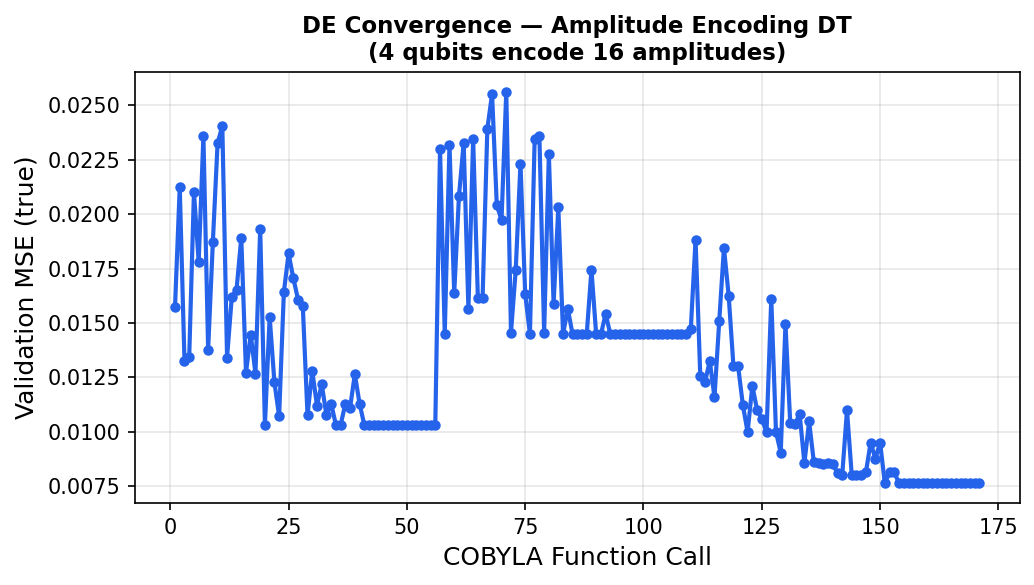

In [ ]:
# ── Cell 7 : DE Convergence Plot ───────────────────────────────────────
conv_file = os.path.join(CACHE_DIR, 'cobyla_convergence.npy')
if os.path.exists(conv_file):
    history = np.load(conv_file)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(history[:, 0], history[:, 1],
            color='#2563EB', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('COBYLA Function Call', fontsize=12)
    ax.set_ylabel('Validation MSE (true)', fontsize=12)
    ax.set_title(
        f'DE Convergence — Amplitude Encoding DT\n'
        f'({n_qubits} qubits encode {dim_amp} amplitudes)',
        fontsize=11, fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No convergence history (weights loaded from cache).')

In [ ]:
# ── Cell 8 : Quantum Feature Computation (train + val + test) ──────────────
if (os.path.exists(X_TRAIN_Q_FILE)
        and os.path.exists(X_VAL_Q_FILE)
        and os.path.exists(X_TEST_Q_FILE)):
    print('Loading quantum features from cache...')
    X_train_q = np.load(X_TRAIN_Q_FILE)
    X_val_q   = np.load(X_VAL_Q_FILE)
    X_test_q  = np.load(X_TEST_Q_FILE)
else:
    print('Computing quantum features (train)...')
    X_train_q = quantum_feature_map(X_train, best_weights, circuit_default, verbose=True)
    np.save(X_TRAIN_Q_FILE, X_train_q)

    print('Computing quantum features (val)...')
    X_val_q = quantum_feature_map(X_val, best_weights, circuit_default, verbose=True)
    np.save(X_VAL_Q_FILE, X_val_q)

    print('Computing quantum features (test)...')
    X_test_q = quantum_feature_map(X_test, best_weights, circuit_default, verbose=True)
    np.save(X_TEST_Q_FILE, X_test_q)

print(f'Shapes  — train_q: {X_train_q.shape}  val_q: {X_val_q.shape}  test_q: {X_test_q.shape}')
print(f'Range   — min: {X_train_q.min():.4f}  max: {X_train_q.max():.4f}  '
      f'(expected in [-1, 1] as PauliZ expectation values)')
print(f'Compression: {dim_amp} padded features → {n_qubits} quantum features.')

Computing quantum features (train)...
  Feature map: 917/9174 samples
  Feature map: 1834/9174 samples
  Feature map: 2751/9174 samples
  Feature map: 3668/9174 samples
  Feature map: 4585/9174 samples
  Feature map: 5502/9174 samples
  Feature map: 6419/9174 samples
  Feature map: 7336/9174 samples
  Feature map: 8253/9174 samples
  Feature map: 9170/9174 samples
Computing quantum features (val)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 1960/1966 samples
Computing quantum features (test)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature

In [ ]:
# ── Cell 9 : Model Training — DT Classical & DT Hybrid ─────────────────────
#
# FIX 1: models cached with joblib (not re-tuned on every run).
# FIX 2: param_dist expanded with splitter + max_features.
# Both models use IDENTICAL RandomizedSearchCV setup (symmetric comparison).

DT_PARAM_DIST = {
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', None],
    'splitter':          ['best', 'random']
}


def tune_dt(X_tr, Y_tr, label='', n_iter=20):
    """RandomizedSearchCV on DT — identical for classical and hybrid."""
    print(f'  Tuning {label}  ({n_iter} iter, {N_SPLITS_CV}-fold CV)...')
    dt = DecisionTreeRegressor(random_state=SEED)
    search = RandomizedSearchCV(
        dt, DT_PARAM_DIST,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_tr, Y_tr)
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV MSE: {-search.best_score_:.6f}')
    return search.best_estimator_


print('\n── Classical DT (raw padded features, {}-dim) ──'.format(dim_amp))
if os.path.exists(MODEL_CLASSICAL_FILE):
    dt_classical = load(MODEL_CLASSICAL_FILE)
    print('  Loaded from cache.')
else:
    dt_classical = tune_dt(X_train, Y_train, label='Classical DT')
    dump(dt_classical, MODEL_CLASSICAL_FILE)

print('\n── Hybrid DT (amplitude quantum features, {}-dim) ──'.format(n_qubits))
if os.path.exists(MODEL_HYBRID_FILE):
    dt_hybrid = load(MODEL_HYBRID_FILE)
    print('  Loaded from cache.')
else:
    dt_hybrid = tune_dt(X_train_q, Y_train, label='Hybrid DT')
    dump(dt_hybrid, MODEL_HYBRID_FILE)

print('\nBoth models trained.')


── Classical DT (raw padded features, 16-dim) ──
  Tuning Classical DT  (20 iter, 5-fold CV)...
  Best params: {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}
  Best CV MSE: 0.004217

── Hybrid DT (amplitude quantum features, 4-dim) ──
  Tuning Hybrid DT  (20 iter, 5-fold CV)...
  Best params: {'splitter': 'random', 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None}
  Best CV MSE: 0.011482

Both models trained.


In [ ]:
# ── Cell 10 : 5-Fold Cross-Validation ────────────────────────────────────

X_trainval   = np.vstack([X_train,   X_val])
X_trainval_q = np.vstack([X_train_q, X_val_q])
Y_trainval   = np.concatenate([Y_train, Y_val])

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
cv_scores = {'classical': [], 'hybrid': []}

print(f'Running {N_SPLITS_CV}-Fold CV on X_trainval ({len(Y_trainval)} samples)...')

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    dt_c = DecisionTreeRegressor(**dt_classical.get_params())
    dt_c.fit(X_trainval[tr_idx], Y_trainval[tr_idx])
    pred_c = dt_c.predict(X_trainval[vl_idx])
    cv_scores['classical'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_c),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_c),
        'r2':       r2_score(Y_trainval[vl_idx], pred_c),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_c)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_c)[0]
    })

    dt_h = DecisionTreeRegressor(**dt_hybrid.get_params())
    dt_h.fit(X_trainval_q[tr_idx], Y_trainval[tr_idx])
    pred_h = dt_h.predict(X_trainval_q[vl_idx])
    cv_scores['hybrid'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_h),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_h),
        'r2':       r2_score(Y_trainval[vl_idx], pred_h),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_h)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_h)[0]
    })

    print(f'  Fold {fold+1}/{N_SPLITS_CV}  '
          f'Classical R²={cv_scores["classical"][-1]["r2"]:.4f}  '
          f'Hybrid R²={cv_scores["hybrid"][-1]["r2"]:.4f}')


def cv_summary(scores, label):
    keys = ['mse', 'mae', 'r2', 'pearson', 'spearman']
    return pd.Series(
        {k: f"{np.mean([s[k] for s in scores]):.4f} ± {np.std([s[k] for s in scores]):.4f}"
         for k in keys},
        name=label
    )

cv_df = pd.DataFrame([
    cv_summary(cv_scores['classical'], 'Classical DT'),
    cv_summary(cv_scores['hybrid'],    'Hybrid DT (amplitude)')
])

print(f'\n── {N_SPLITS_CV}-Fold CV Results (mean ± std) ──')
print(cv_df.to_string())

Running 5-Fold CV on X_trainval (11140 samples)...
  Fold 1/5  Classical R²=0.7790  Hybrid R²=0.3366
  Fold 2/5  Classical R²=0.8093  Hybrid R²=0.3636
  Fold 3/5  Classical R²=0.7392  Hybrid R²=0.3179
  Fold 4/5  Classical R²=0.7648  Hybrid R²=0.3788
  Fold 5/5  Classical R²=0.7973  Hybrid R²=0.3708

── 5-Fold CV Results (mean ± std) ──
                                   mse              mae               r2          pearson         spearman
Classical DT           0.0039 ± 0.0003  0.0412 ± 0.0010  0.7779 ± 0.0246  0.8826 ± 0.0139  0.8505 ± 0.0118
Hybrid DT (amplitude)  0.0114 ± 0.0002  0.0784 ± 0.0009  0.3536 ± 0.0228  0.6018 ± 0.0158  0.5870 ± 0.0063


In [ ]:
# ── Cell 11 : Wilcoxon Signed-Rank Test ─────────────────────────────────

r2_c  = [s['r2']  for s in cv_scores['classical']]
r2_h  = [s['r2']  for s in cv_scores['hybrid']]
mse_c = [s['mse'] for s in cv_scores['classical']]
mse_h = [s['mse'] for s in cv_scores['hybrid']]

stat_r2,  p_r2  = wilcoxon(r2_h,  r2_c,  alternative='greater')
stat_mse, p_mse = wilcoxon(mse_c, mse_h, alternative='greater')

print('── Wilcoxon Test (one-sided: hybrid > classical) ──')
print(f'  R²  stat={stat_r2:.3f}   p={p_r2:.4f}   '
      f'{"significant (p<0.05)" if p_r2  < 0.05 else "not significant"}')
print(f'  MSE stat={stat_mse:.3f}  p={p_mse:.4f}   '
      f'{"significant (p<0.05)" if p_mse < 0.05 else "not significant"}')
print('Note: with N=5 folds, Wilcoxon has limited power. Report exact p-values.')

── Wilcoxon Test (one-sided: hybrid > classical) ──
  R²  stat=0.000   p=1.0000   not significant
  MSE stat=0.000  p=1.0000   not significant
Note: with N=5 folds, Wilcoxon has limited power. Report exact p-values.


In [ ]:
# ── Cell 12 : Final Holdout Evaluation — X_test touched ONCE ───────────────
#
# FIX: evaluate() no longer calls model.fit() on test data.
# Models were already trained in Cell 9; we only call predict() here.

def evaluate(model, X_te, Y_te, label):
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)   # predict only — no fit()
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)

    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    pr,
        'Spearman rho': sr,
        'Time (s)':     elapsed,
        'Memory (MB)':  peak / 1024**2,
        '_pred':        Y_pred
    }

print('Final evaluation on X_test (touched once):')
res_classical = evaluate(dt_classical, X_test,   Y_test, 'Classical DT')
res_hybrid    = evaluate(dt_hybrid,    X_test_q, Y_test, 'Hybrid DT (amplitude)')

preds = {
    'Classical DT':           res_classical.pop('_pred'),
    'Hybrid DT (amplitude)':  res_hybrid.pop('_pred')
}

results_df = pd.DataFrame([res_classical, res_hybrid]).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho', 'Time (s)', 'Memory (MB)']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())

Final evaluation on X_test (touched once):

── Test Set Results ──
                          MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)
Model                                                                                                
Classical DT           0.0041  0.0642  0.0432  0.7844     0.8861        0.8500    0.0010       0.1519
Hybrid DT (amplitude)  0.0120  0.1093  0.0804  0.3747     0.6129        0.5782    0.0007       0.0619


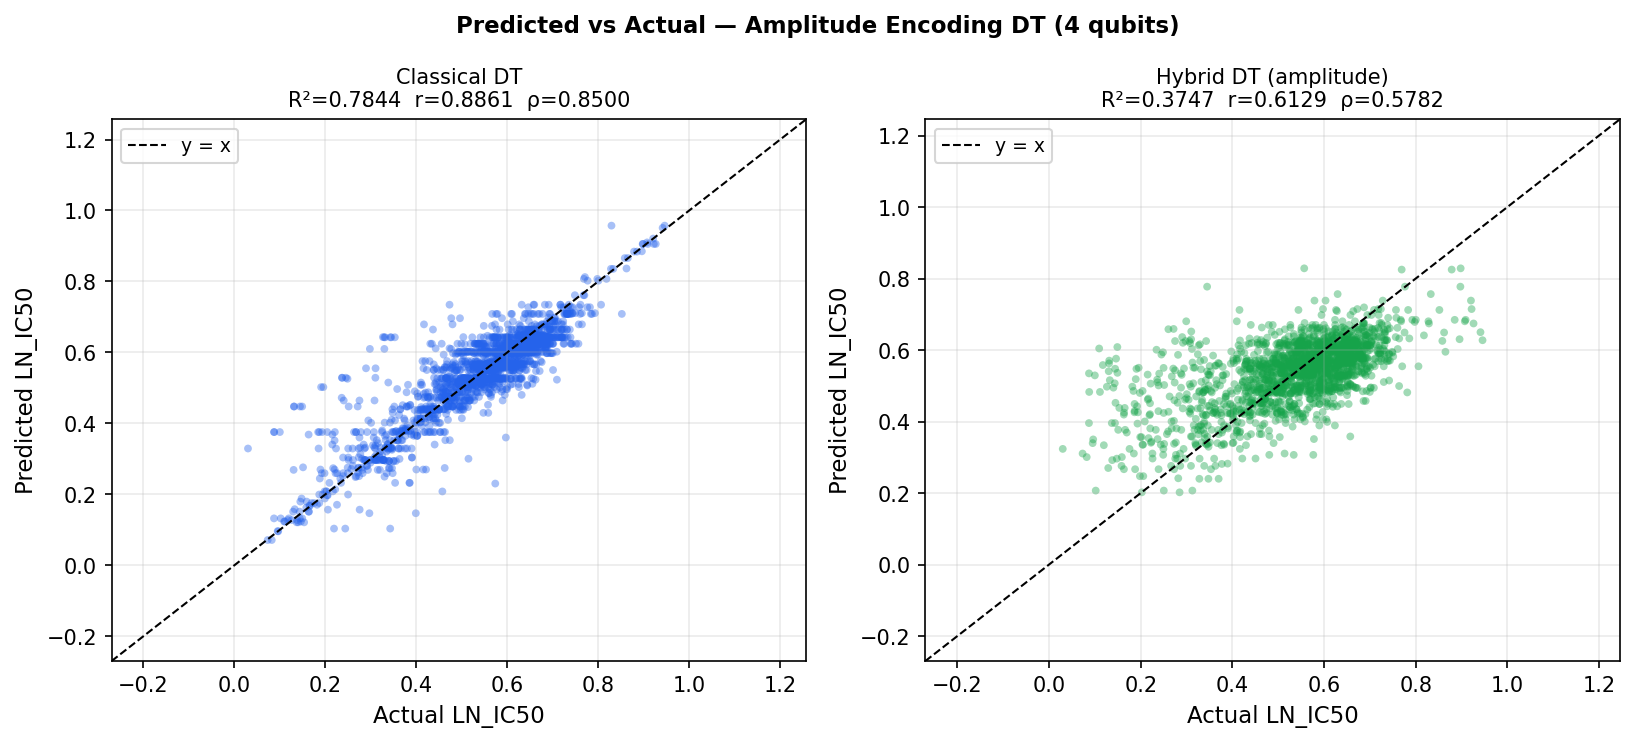

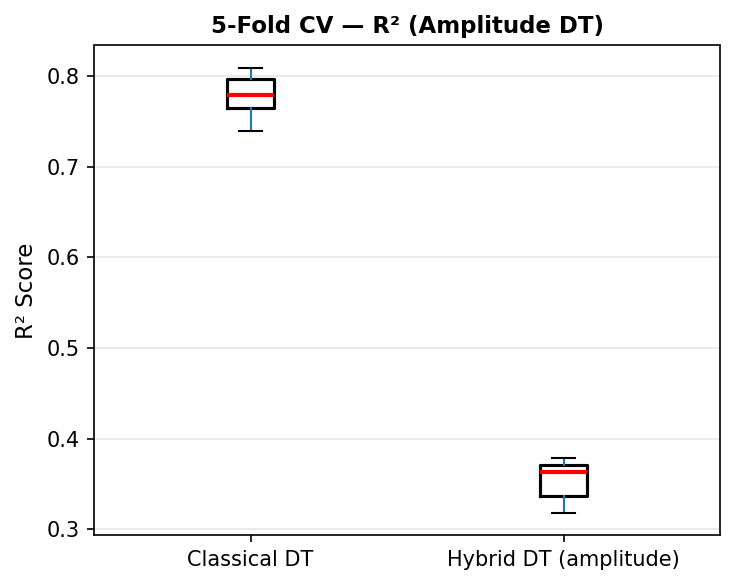

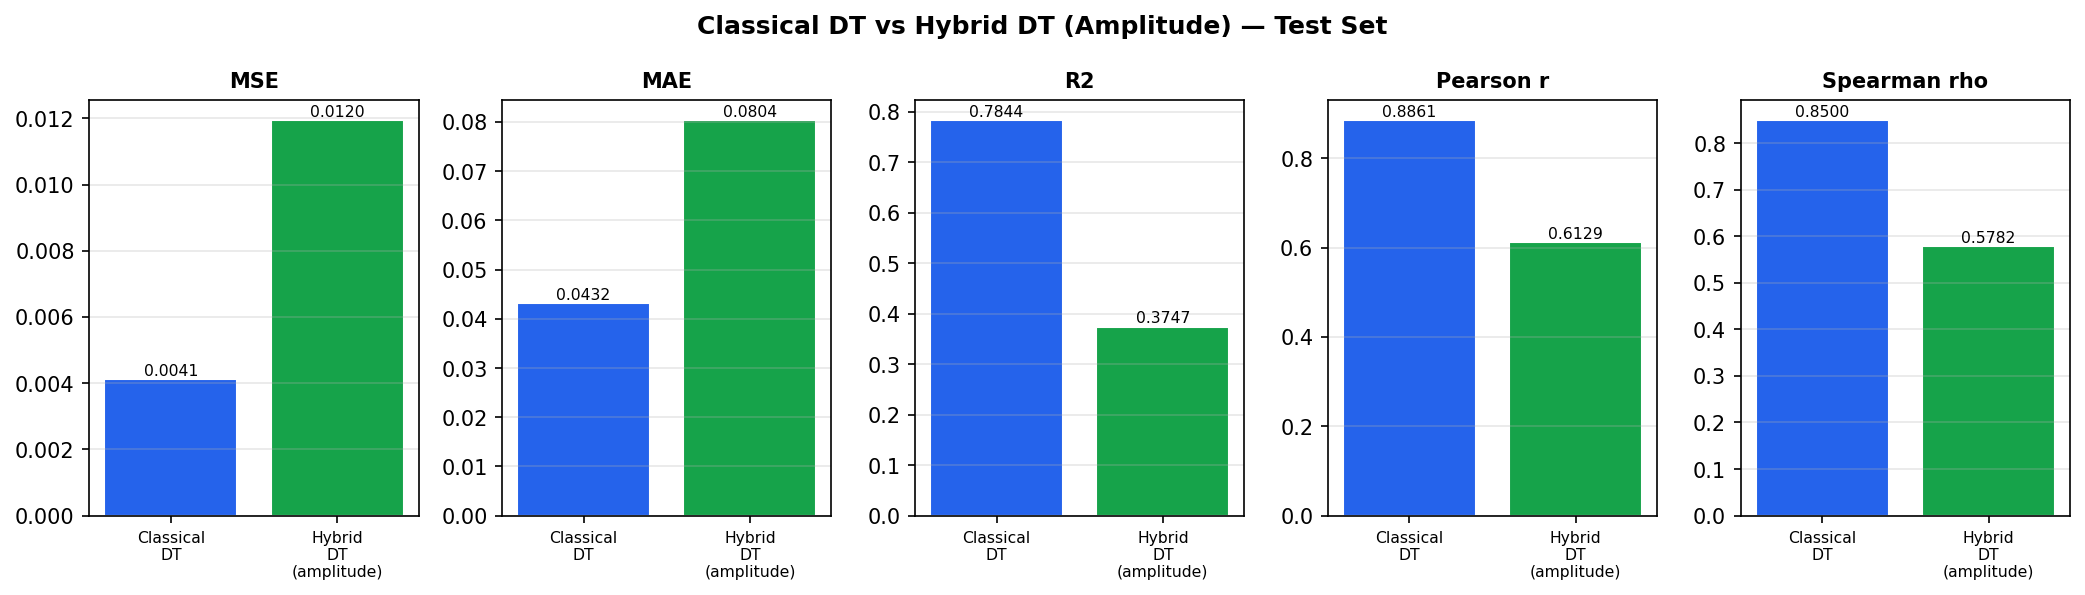

Figures saved to /home/host1-vm4/cache_quantum_amplitude_dt_pub/figures


In [ ]:
# ── Cell 13 : Publication Figures ────────────────────────────────────────

PALETTE = {'Classical DT': '#2563EB', 'Hybrid DT (amplitude)': '#16A34A'}

# ── Figure 2: Predicted vs Actual ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=150)
for ax, (label, color) in zip(axes, PALETTE.items()):
    y_pred = preds[label]
    lims = [min(Y_test.min(), y_pred.min()) - 0.3,
            max(Y_test.max(), y_pred.max()) + 0.3]
    ax.scatter(Y_test, y_pred, alpha=0.4, s=14, color=color, edgecolors='none')
    ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2v = results_df.loc[label, 'R2']
    prv = results_df.loc[label, 'Pearson r']
    srv = results_df.loc[label, 'Spearman rho']
    ax.set_title(f'{label}\nR²={r2v:.4f}  r={prv:.4f}  ρ={srv:.4f}', fontsize=10)
    ax.set_xlabel('Actual LN_IC50', fontsize=11)
    ax.set_ylabel('Predicted LN_IC50', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.suptitle(
    f'Predicted vs Actual — Amplitude Encoding DT ({n_qubits} qubits)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: CV boxplot ──────────────────────────────────────────────
cv_plot_df = pd.DataFrame({
    'Classical DT':           [s['r2'] for s in cv_scores['classical']],
    'Hybrid DT (amplitude)':  [s['r2'] for s in cv_scores['hybrid']]
})
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
cv_plot_df.boxplot(ax=ax, grid=False,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(linewidth=1.5))
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title(f'{N_SPLITS_CV}-Fold CV — R² (Amplitude DT)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_cv_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 4: Metrics bar chart ───────────────────────────────────────
metrics_bar = ['MSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho']
fig, axes = plt.subplots(1, len(metrics_bar), figsize=(14, 4), dpi=150)
colors = list(PALETTE.values())
labels = list(PALETTE.keys())

for ax, metric in zip(axes, metrics_bar):
    vals = [results_df.loc[l, metric] for l in labels]
    bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in labels], fontsize=7.5)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * abs(max(vals) - min(vals)),
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Classical DT vs Hybrid DT (Amplitude) — Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Figures saved to {os.path.abspath(FIGDIR)}')

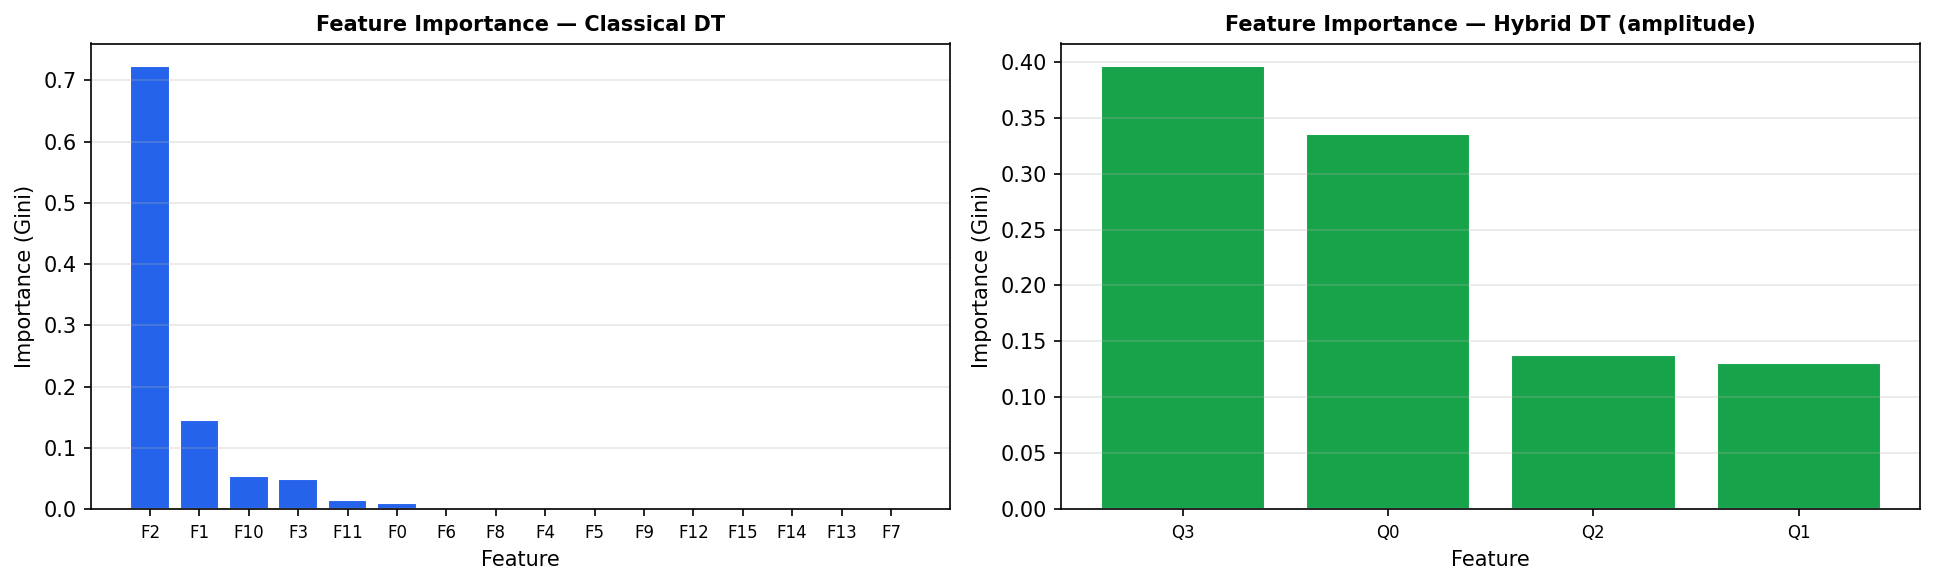

In [ ]:
# ── Cell 14 : Feature Importance ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=150)

for ax, (label, model, feat_names) in zip(axes, [
    ('Classical DT',
     dt_classical,
     [f'F{i}' for i in range(dim_amp)]),
    ('Hybrid DT (amplitude)',
     dt_hybrid,
     [f'Q{i}' for i in range(n_qubits)])
]):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx],
           color=PALETTE[label], edgecolor='white')
    ax.set_xticks(range(len(imp)))
    ax.set_xticklabels([feat_names[i] for i in idx], fontsize=8)
    ax.set_xlabel('Feature', fontsize=10)
    ax.set_ylabel('Importance (Gini)', fontsize=10)
    ax.set_title(f'Feature Importance — {label}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig5_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


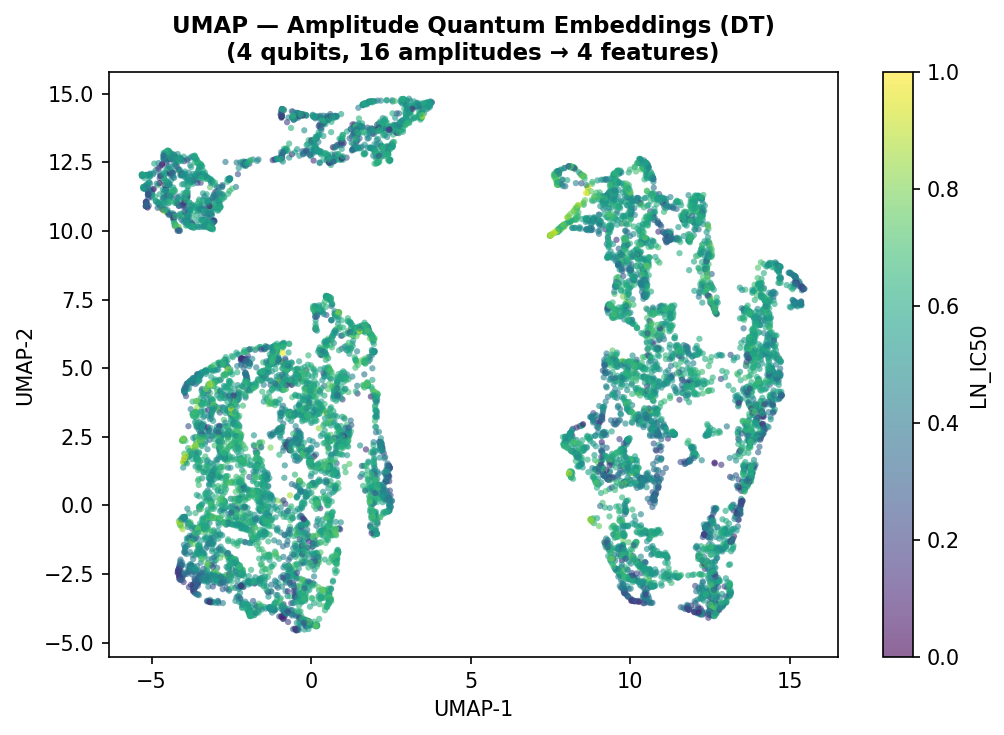

In [ ]:
# ── Cell 15 : UMAP of Quantum Embeddings ─────────────────────────────────
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=SEED,
                        n_neighbors=15, min_dist=0.1)
    X_2d = reducer.fit_transform(X_trainval_q)

    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=Y_trainval, cmap='viridis',
                    s=9, alpha=0.6, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='LN_IC50')
    ax.set_title(
        f'UMAP — Amplitude Quantum Embeddings (DT)\n'
        f'({n_qubits} qubits, {dim_amp} amplitudes → {n_qubits} features)',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('UMAP-1', fontsize=10)
    ax.set_ylabel('UMAP-2', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig6_umap.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('UMAP not available. Install with: pip install umap-learn')